In [1]:
!pip install monai nibabel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 28.6 MB/s eta 0:00:00a 0:00:01


In [2]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

from scipy.ndimage import zoom

import torch
from torch.utils.data import Dataset, DataLoader

from monai.networks.nets import UNet
from monai.losses import DiceCELoss

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-05-09 01:36:06.158208: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778290566.348817      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778290566.405343      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778290566.871209      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778290566.871253      57 computation_placer.cc:1

In [3]:
device = "cuda"

print(device)

cuda


In [4]:
image_dir = "/kaggle/input/datasets/yashsankhe27/lungs-tumor-dataset/lung ct scan/imagesTr"

mask_dir = "/kaggle/input/datasets/yashsankhe27/lungs-tumor-dataset/lung ct scan/labelsTr"

test_image_dir = "/kaggle/input/datasets/yashsankhe27/lungs-tumor-dataset/lung ct scan/imagetesting"

test_mask_dir = "/kaggle/input/datasets/yashsankhe27/lungs-tumor-dataset/lung ct scan/labeltesting"

In [5]:
TARGET_SHAPE = (224,224,224)

In [7]:
def preprocess_volume(image_path, mask_path):

    image = nib.load(image_path).get_fdata().astype(np.float32)

    mask = nib.load(mask_path).get_fdata().astype(np.float32)

    # normalize
    image = (image - image.min()) / (
        image.max() - image.min() + 1e-8
    )

    # resize
    factors = (
        TARGET_SHAPE[0] / image.shape[0],
        TARGET_SHAPE[1] / image.shape[1],
        TARGET_SHAPE[2] / image.shape[2]
    )

    image = zoom(image, factors, order=1)

    mask = zoom(mask, factors, order=0)

    image = torch.tensor(image).unsqueeze(0)

    mask = torch.tensor(mask).unsqueeze(0)

    return image.float(), mask.float()

In [8]:
class LungSegmentationDataset(Dataset):

    def __init__(self, image_dir, mask_dir):

        self.image_paths = sorted([
            os.path.join(image_dir, f)
            for f in os.listdir(image_dir)
            if f.endswith(".nii")
            and not f.startswith("._")
        ])

        self.mask_paths = sorted([
            os.path.join(mask_dir, f)
            for f in os.listdir(mask_dir)
            if f.endswith(".nii")
            and not f.startswith("._")
        ])

    def __len__(self):

        return len(self.image_paths)

    def __getitem__(self, idx):

        image, mask = preprocess_volume(
            self.image_paths[idx],
            self.mask_paths[idx]
        )

        return image, mask

In [9]:
dataset = LungSegmentationDataset(
    image_dir,
    mask_dir
)

print("Dataset Size:", len(dataset))

Dataset Size: 34


In [10]:
import os

print(os.listdir(image_dir)[:10])

['lung_022.nii', '._lung_018.nii.gz', '._lung_001.nii.gz', '._lung_004.nii.gz', 'lung_043.nii', 'lung_015.nii', 'lung_023.nii', '._lung_023.nii.gz', 'lung_049.nii', '._lung_046.nii.gz']


In [11]:
loader = DataLoader(
    dataset,
    batch_size=1,
    shuffle=True
)

In [12]:
model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=1,
    channels=(8,16,32,64),
    strides=(2,2,2),
    num_res_units=2
).to(device)

In [13]:
loss_function = DiceCELoss(
    sigmoid=True,
    squared_pred=True,
    smooth_nr=1e-5,
    smooth_dr=1e-5
)

In [14]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [15]:
EPOCHS = 30

for epoch in range(EPOCHS):

    model.train()

    epoch_loss = 0

    # reduce LR later
    if epoch == 10:

        optimizer.param_groups[0]['lr'] = 5e-5

        print("Learning rate reduced")

    for images, masks in loader:

        images = images.to(device)

        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_function(outputs, masks)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)

    print(f"Epoch {epoch+1}/{EPOCHS}")

    print(f"Loss: {avg_loss:.4f}")

    # save checkpoint
    torch.save(
        model.state_dict(),
        f"/kaggle/working/checkpoint_epoch_{epoch+1}.pth"
    )

Epoch 1/30
Loss: 1.7578
Epoch 2/30
Loss: 1.7034
Epoch 3/30
Loss: 1.6822
Epoch 4/30
Loss: 1.6701
Epoch 5/30
Loss: 1.6625
Epoch 6/30
Loss: 1.6575
Epoch 7/30
Loss: 1.6535
Epoch 8/30
Loss: 1.6499
Epoch 9/30
Loss: 1.6468
Epoch 10/30
Loss: 1.6439
Learning rate reduced
Epoch 11/30
Loss: 1.6419
Epoch 12/30
Loss: 1.6406
Epoch 13/30
Loss: 1.6394
Epoch 14/30
Loss: 1.6382
Epoch 15/30
Loss: 1.6371
Epoch 16/30
Loss: 1.6359
Epoch 17/30
Loss: 1.6348
Epoch 18/30
Loss: 1.6338
Epoch 19/30
Loss: 1.6327
Epoch 20/30
Loss: 1.6317
Epoch 21/30
Loss: 1.6306
Epoch 22/30
Loss: 1.6296
Epoch 23/30
Loss: 1.6286
Epoch 24/30
Loss: 1.6276
Epoch 25/30
Loss: 1.6265
Epoch 26/30
Loss: 1.6255
Epoch 27/30
Loss: 1.6245
Epoch 28/30
Loss: 1.6230
Epoch 29/30
Loss: 1.6190
Epoch 30/30
Loss: 1.6060


In [16]:
torch.save(
    model.state_dict(),
    "/kaggle/working/lung_unet_30epochs.pth"
)

In [18]:
from monai.metrics import DiceMetric

In [19]:
model.load_state_dict(
    torch.load(
        "/kaggle/working/lung_unet_30epochs.pth"
    )
)

model.eval()

print("Model loaded!")

Model loaded!


In [20]:
test_files = sorted([
    f for f in os.listdir(test_image_dir)
    if f.endswith(".nii")
    and not f.startswith("._")
])

print("Total test scans:", len(test_files))

Total test scans: 14


In [22]:
dice_metric = DiceMetric(
    include_background=False,
    reduction="mean"
)

In [25]:
scores = []

model.eval()

with torch.no_grad():

    for file_name in test_files:

        image_path = os.path.join(
            test_image_dir,
            file_name
        )

        mask_path = os.path.join(
            test_mask_dir,
            file_name
        )

        image, mask = preprocess_volume(
            image_path,
            mask_path
        )

        image = image.unsqueeze(0).to(device)

        mask = mask.unsqueeze(0).to(device)

        prediction = model(image)

        prediction = torch.sigmoid(prediction)

        prediction = (prediction > 0.6).float()

        dice_metric(prediction, mask)

        score = dice_metric.aggregate().item()

        scores.append(score)

        dice_metric.reset()

        print(f"{file_name} Dice Score: {score:.4f}")

lung_051.nii Dice Score: 0.0045
lung_053.nii Dice Score: 0.0005
lung_054.nii Dice Score: 0.0009
lung_055.nii Dice Score: 0.0345
lung_057.nii Dice Score: 0.0025
lung_058.nii Dice Score: 0.0000
lung_059.nii Dice Score: 0.0045
lung_061.nii Dice Score: 0.0000
lung_062.nii Dice Score: 0.0048
lung_064.nii Dice Score: 0.0003
lung_065.nii Dice Score: 0.0005
lung_066.nii Dice Score: 0.0018
lung_069.nii Dice Score: 0.0006
lung_070.nii Dice Score: 0.0000


In [26]:
file_name = "lung_055.nii"

image_path = os.path.join(
    test_image_dir,
    file_name
)

mask_path = os.path.join(
    test_mask_dir,
    file_name
)

print(image_path)

/kaggle/input/datasets/yashsankhe27/lungs-tumor-dataset/lung ct scan/imagetesting/lung_055.nii


In [27]:
image, mask = preprocess_volume(
    image_path,
    mask_path
)

print(image.shape)

print(mask.shape)

torch.Size([1, 224, 224, 224])
torch.Size([1, 224, 224, 224])


In [28]:
model.eval()

with torch.no_grad():

    prediction = model(
        image.unsqueeze(0).to(device)
    )

prediction = torch.sigmoid(prediction)

prediction = (prediction > 0.6).float()

prediction = prediction.squeeze().cpu().numpy()

print("Inference complete!")

Inference complete!


In [29]:
img = image.squeeze().numpy()

gt_mask = mask.squeeze().numpy()

In [30]:
for i in range(gt_mask.shape[2]):

    if np.max(gt_mask[:,:,i]) > 0:

        print("Tumor Slice:", i)

Tumor Slice: 133
Tumor Slice: 134
Tumor Slice: 135
Tumor Slice: 136
Tumor Slice: 137
Tumor Slice: 138
Tumor Slice: 139
Tumor Slice: 140
Tumor Slice: 141
Tumor Slice: 142
Tumor Slice: 143
Tumor Slice: 144
Tumor Slice: 145
Tumor Slice: 146
Tumor Slice: 147
Tumor Slice: 148
Tumor Slice: 149
Tumor Slice: 150
Tumor Slice: 151
Tumor Slice: 152
Tumor Slice: 153
Tumor Slice: 154
Tumor Slice: 155
Tumor Slice: 156
Tumor Slice: 157
Tumor Slice: 158
Tumor Slice: 159


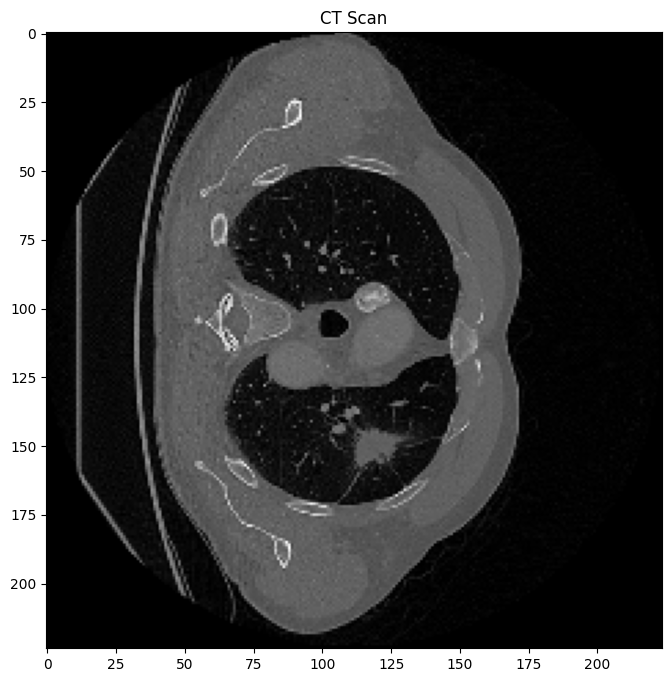

In [31]:
slice_idx = 147

plt.figure(figsize=(8,8))

plt.imshow(
    img[:,:,slice_idx],
    cmap="gray"
)

plt.title("CT Scan")

plt.show()

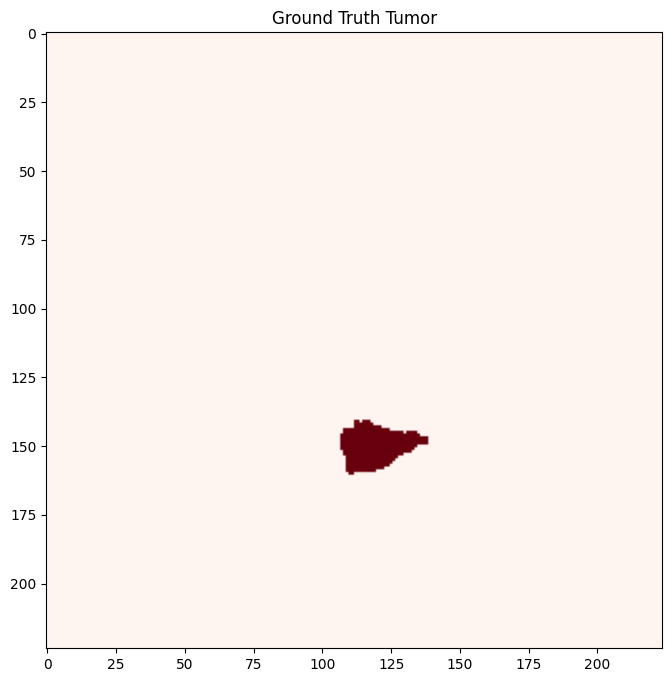

In [32]:
plt.figure(figsize=(8,8))

plt.imshow(
    gt_mask[:,:,slice_idx],
    cmap="Reds"
)

plt.title("Ground Truth Tumor")

plt.show()

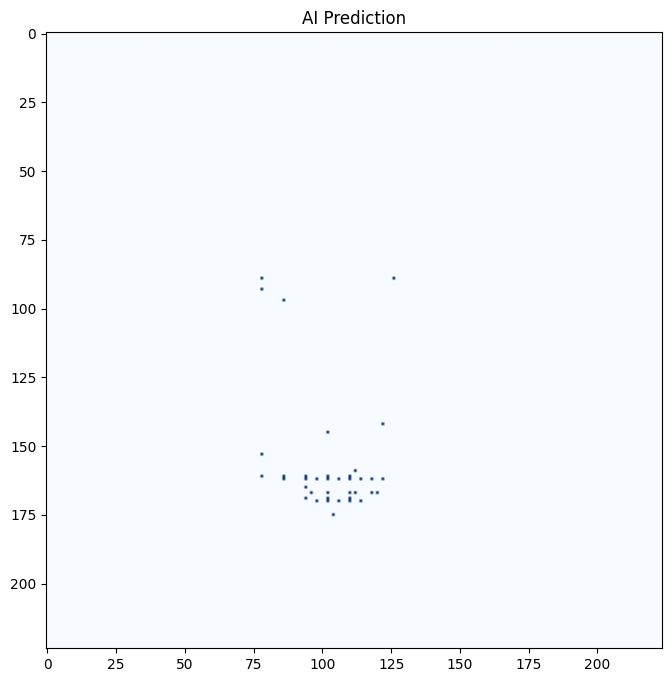

In [33]:
plt.figure(figsize=(8,8))

plt.imshow(
    prediction[:,:,slice_idx],
    cmap="Blues"
)

plt.title("AI Prediction")

plt.show()

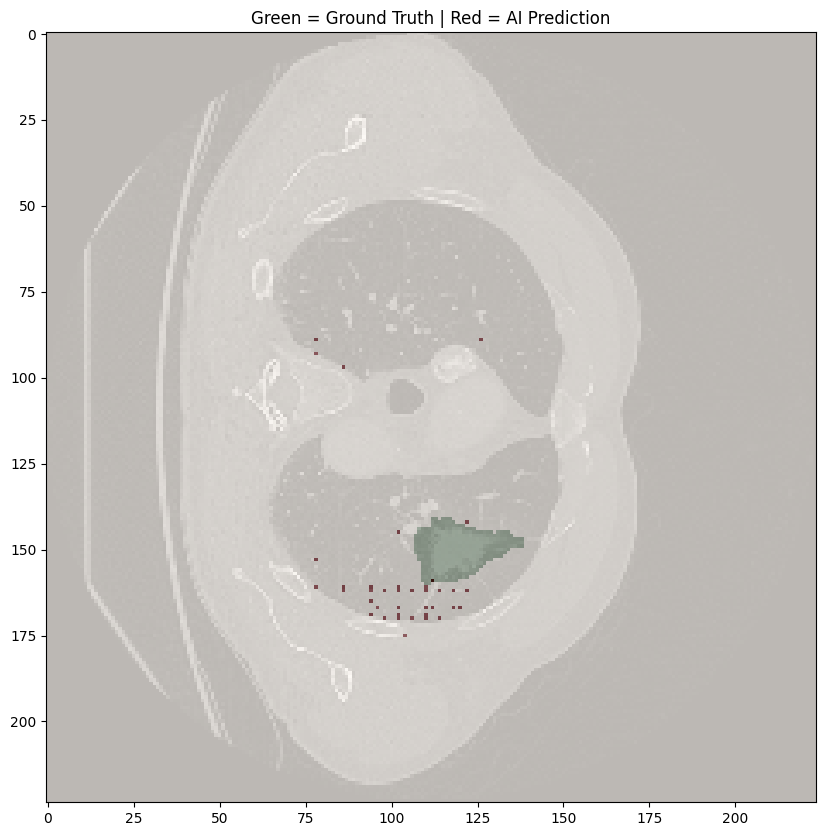

In [34]:
plt.figure(figsize=(10,10))

plt.imshow(
    img[:,:,slice_idx],
    cmap="gray"
)

# Ground Truth
plt.imshow(
    gt_mask[:,:,slice_idx],
    cmap="Greens",
    alpha=0.5
)

# Prediction
plt.imshow(
    prediction[:,:,slice_idx],
    cmap="Reds",
    alpha=0.5
)

plt.title(
    "Green = Ground Truth | Red = AI Prediction"
)

plt.show()

In [36]:
PATCH_SIZE = 96

In [37]:
def extract_patch(image, mask, patch_size=96):

    # find tumor coordinates
    coords = np.argwhere(mask > 0)

    # fallback if empty mask
    if len(coords) == 0:

        center = np.array(mask.shape) // 2

    else:

        center = coords[np.random.randint(len(coords))]

    x, y, z = center

    half = patch_size // 2

    # boundaries
    x1 = max(0, x - half)
    x2 = min(mask.shape[0], x + half)

    y1 = max(0, y - half)
    y2 = min(mask.shape[1], y + half)

    z1 = max(0, z - half)
    z2 = min(mask.shape[2], z + half)

    image_patch = image[
        x1:x2,
        y1:y2,
        z1:z2
    ]

    mask_patch = mask[
        x1:x2,
        y1:y2,
        z1:z2
    ]

    # pad if needed
    pad_x = patch_size - image_patch.shape[0]
    pad_y = patch_size - image_patch.shape[1]
    pad_z = patch_size - image_patch.shape[2]

    image_patch = np.pad(
        image_patch,
        (
            (0,pad_x),
            (0,pad_y),
            (0,pad_z)
        )
    )

    mask_patch = np.pad(
        mask_patch,
        (
            (0,pad_x),
            (0,pad_y),
            (0,pad_z)
        )
    )

    return image_patch, mask_patch

In [38]:
def preprocess_volume(image_path, mask_path):

    image = nib.load(image_path).get_fdata().astype(np.float32)

    mask = nib.load(mask_path).get_fdata().astype(np.float32)

    # normalize
    image = (image - image.min()) / (
        image.max() - image.min() + 1e-8
    )

    # resize
    factors = (
        TARGET_SHAPE[0] / image.shape[0],
        TARGET_SHAPE[1] / image.shape[1],
        TARGET_SHAPE[2] / image.shape[2]
    )

    image = zoom(image, factors, order=1)

    mask = zoom(mask, factors, order=0)

    # extract tumor patch
    image, mask = extract_patch(
        image,
        mask,
        patch_size=PATCH_SIZE
    )

    image = torch.tensor(image).unsqueeze(0)

    mask = torch.tensor(mask).unsqueeze(0)

    return image.float(), mask.float()

In [39]:
image, mask = preprocess_volume(
    dataset.image_paths[0],
    dataset.mask_paths[0]
)

print(image.shape)

print(mask.shape)

torch.Size([1, 96, 96, 96])
torch.Size([1, 96, 96, 96])


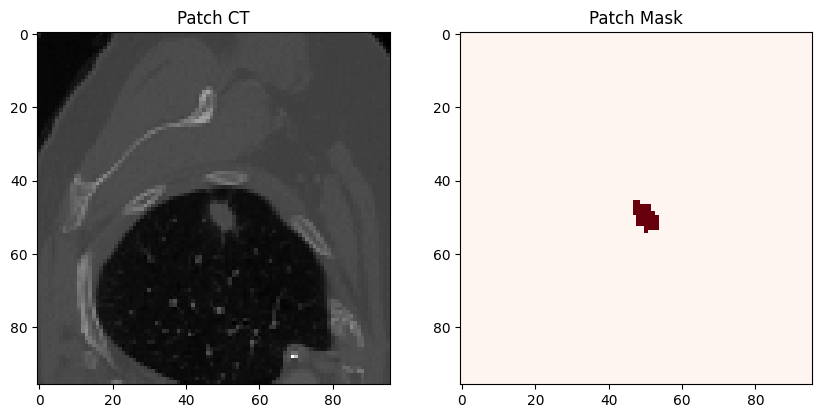

In [40]:
img = image.squeeze().numpy()

msk = mask.squeeze().numpy()

slice_idx = 48

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)

plt.imshow(img[:,:,slice_idx], cmap="gray")

plt.title("Patch CT")

plt.subplot(1,2,2)

plt.imshow(msk[:,:,slice_idx], cmap="Reds")

plt.title("Patch Mask")

plt.show()

In [41]:
dataset = LungSegmentationDataset(
    image_dir,
    mask_dir
)

print("Dataset Size:", len(dataset))

Dataset Size: 34


In [42]:
loader = DataLoader(
    dataset,
    batch_size=1,
    shuffle=True
)

In [43]:
model.load_state_dict(
    torch.load(
        "/kaggle/working/lung_unet_30epochs.pth"
    )
)

model.train()

print("Previous model loaded!")

Previous model loaded!


In [44]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=5e-5
)

In [45]:
loss_function = DiceCELoss(
    sigmoid=True,
    squared_pred=True,
    smooth_nr=1e-5,
    smooth_dr=1e-5
)

In [46]:
EPOCHS = 20

for epoch in range(EPOCHS):

    model.train()

    epoch_loss = 0

    for images, masks in loader:

        images = images.to(device)

        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_function(outputs, masks)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)

    print(f"Patch Epoch {epoch+1}/{EPOCHS}")

    print(f"Loss: {avg_loss:.4f}")

Patch Epoch 1/20
Loss: 1.5778
Patch Epoch 2/20
Loss: 1.5679
Patch Epoch 3/20
Loss: 1.5581
Patch Epoch 4/20
Loss: 1.5489
Patch Epoch 5/20
Loss: 1.5402
Patch Epoch 6/20
Loss: 1.5314
Patch Epoch 7/20
Loss: 1.5218
Patch Epoch 8/20
Loss: 1.5136
Patch Epoch 9/20
Loss: 1.5053
Patch Epoch 10/20
Loss: 1.4977
Patch Epoch 11/20
Loss: 1.4908
Patch Epoch 12/20
Loss: 1.4829
Patch Epoch 13/20
Loss: 1.4759
Patch Epoch 14/20
Loss: 1.4693
Patch Epoch 15/20
Loss: 1.4622
Patch Epoch 16/20
Loss: 1.4550
Patch Epoch 17/20
Loss: 1.4495
Patch Epoch 18/20
Loss: 1.4435
Patch Epoch 19/20
Loss: 1.4365
Patch Epoch 20/20
Loss: 1.4310


In [48]:
torch.save(
    model.state_dict(),
    "/kaggle/working/lung_unet_patch.pth"
)


In [51]:
model.load_state_dict(
    torch.load(
        "/kaggle/working/lung_unet_patch.pth"
    )
)

model.eval()

print("Patch model loaded!")


Patch model loaded!


In [52]:
from monai.metrics import DiceMetric

In [54]:
test_files = sorted([
    f for f in os.listdir(test_image_dir)
    if f.endswith(".nii")
    and not f.startswith("._")
])

print("Total test scans:", len(test_files))

Total test scans: 14


In [59]:
dice_metric = DiceMetric(
    include_background=False,
    reduction="mean"
)

In [60]:
scores = []

model.eval()

with torch.no_grad():

    for file_name in test_files:

        image_path = os.path.join(
            test_image_dir,
            file_name
        )

        mask_path = os.path.join(
            test_mask_dir,
            file_name
        )

        image, mask = preprocess_volume(
            image_path,
            mask_path
        )

        image = image.unsqueeze(0).to(device)

        mask = mask.unsqueeze(0).to(device)

        prediction = model(image)

        prediction = torch.sigmoid(prediction)

        prediction = (prediction > 0.6).float()

        dice_metric(prediction, mask)

        score = dice_metric.aggregate().item()

        scores.append(score)

        dice_metric.reset()

        print(f"{file_name} Dice Score: {score:.4f}")

lung_051.nii Dice Score: 0.0007
lung_053.nii Dice Score: 0.3451
lung_054.nii Dice Score: 0.3034
lung_055.nii Dice Score: 0.5395
lung_057.nii Dice Score: 0.0791
lung_058.nii Dice Score: 0.0446
lung_059.nii Dice Score: 0.0000
lung_061.nii Dice Score: 0.0500
lung_062.nii Dice Score: 0.0048
lung_064.nii Dice Score: 0.3327
lung_065.nii Dice Score: 0.6788
lung_066.nii Dice Score: 0.0233
lung_069.nii Dice Score: 0.0000
lung_070.nii Dice Score: 0.0013


In [61]:
avg_dice = sum(scores) / len(scores)

print("Average Dice Score:", avg_dice)

Average Dice Score: 0.17165851352703093


In [62]:
file_name = "lung_065.nii"

image_path = os.path.join(
    test_image_dir,
    file_name
)

mask_path = os.path.join(
    test_mask_dir,
    file_name
)

In [64]:
image, mask = preprocess_volume(
    image_path,
    mask_path
)

In [65]:
with torch.no_grad():

    prediction = model(
        image.unsqueeze(0).to(device)
    )

prediction = torch.sigmoid(prediction)

prediction = (prediction > 0.6).float()

prediction = prediction.squeeze().cpu().numpy()

print("Inference complete!")

Inference complete!


In [66]:
img = image.squeeze().numpy()

gt_mask = mask.squeeze().numpy()

In [67]:
for i in range(gt_mask.shape[2]):

    if np.max(gt_mask[:,:,i]) > 0:

        print("Tumor Slice:", i)

Tumor Slice: 43
Tumor Slice: 44
Tumor Slice: 45
Tumor Slice: 46
Tumor Slice: 47
Tumor Slice: 48
Tumor Slice: 49
Tumor Slice: 50
Tumor Slice: 51
Tumor Slice: 52
Tumor Slice: 53
Tumor Slice: 54
Tumor Slice: 55
Tumor Slice: 56
Tumor Slice: 57
Tumor Slice: 58
Tumor Slice: 59
Tumor Slice: 60
Tumor Slice: 61
Tumor Slice: 62
Tumor Slice: 63
Tumor Slice: 64
Tumor Slice: 65
Tumor Slice: 66
Tumor Slice: 67
Tumor Slice: 68
Tumor Slice: 69
Tumor Slice: 70
Tumor Slice: 71
Tumor Slice: 72
Tumor Slice: 73
Tumor Slice: 74
Tumor Slice: 75


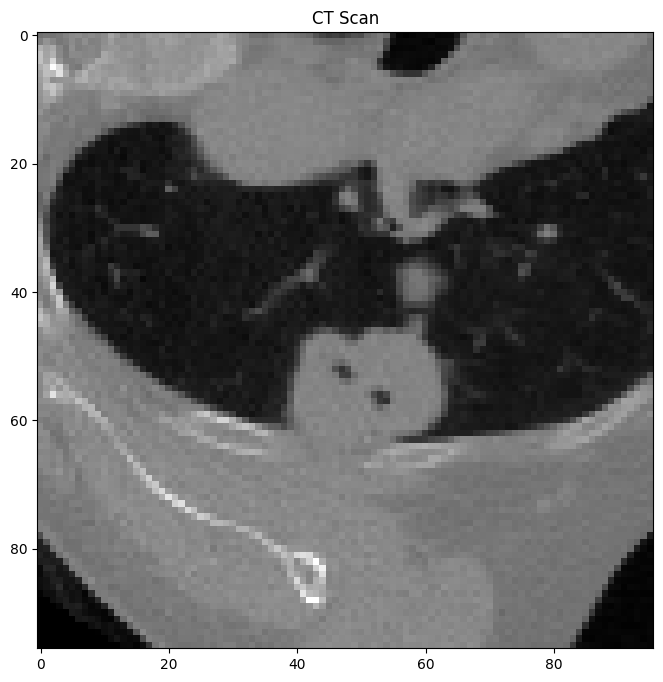

In [68]:
slice_idx = 60

plt.figure(figsize=(8,8))

plt.imshow(
    img[:,:,slice_idx],
    cmap="gray"
)

plt.title("CT Scan")

plt.show()

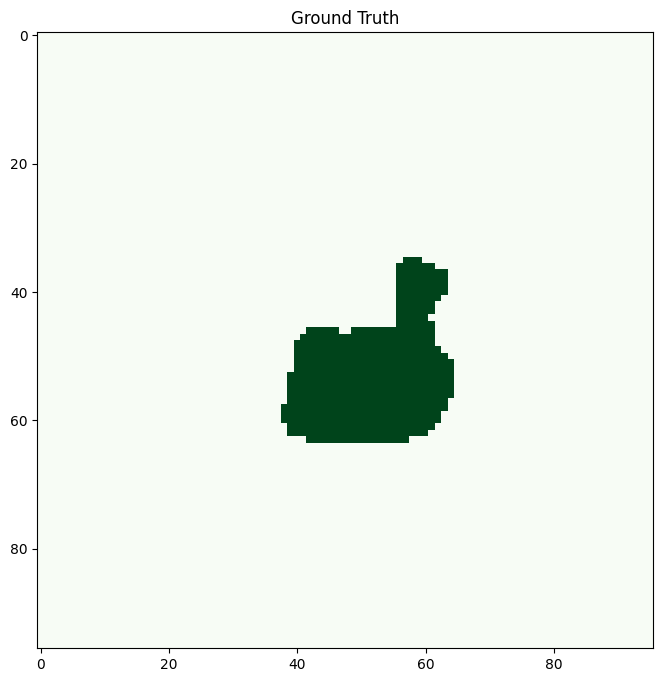

In [69]:
plt.figure(figsize=(8,8))

plt.imshow(
    gt_mask[:,:,slice_idx],
    cmap="Greens"
)

plt.title("Ground Truth")

plt.show()

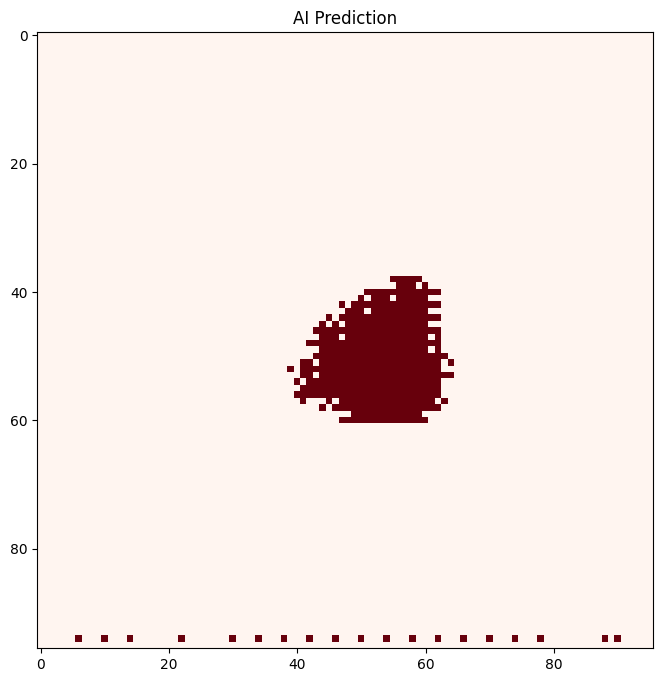

In [70]:
plt.figure(figsize=(8,8))

plt.imshow(
    prediction[:,:,slice_idx],
    cmap="Reds"
)

plt.title("AI Prediction")

plt.show()

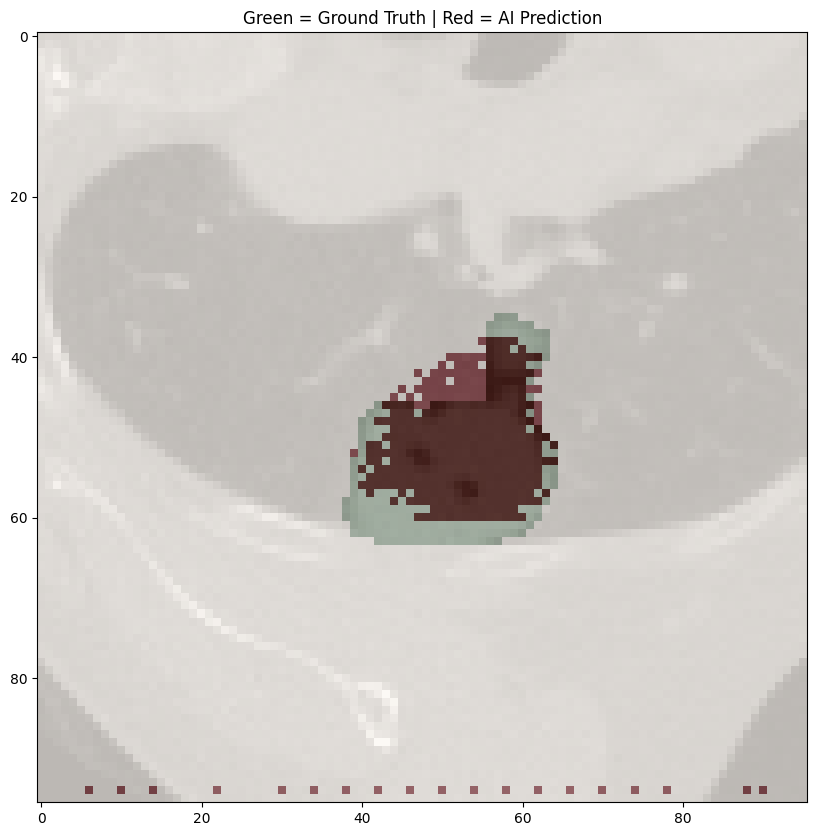

In [71]:
plt.figure(figsize=(10,10))

plt.imshow(
    img[:,:,slice_idx],
    cmap="gray"
)

# Ground truth
plt.imshow(
    gt_mask[:,:,slice_idx],
    cmap="Greens",
    alpha=0.5
)

# AI prediction
plt.imshow(
    prediction[:,:,slice_idx],
    cmap="Reds",
    alpha=0.5
)

plt.title(
    "Green = Ground Truth | Red = AI Prediction"
)

plt.show()

In [77]:
torch.save(
    model.state_dict(),
    "Lung_Tumor_ct_v1.pth"
)

In [78]:
correct = 0

total = 0

In [79]:
model.eval()

with torch.no_grad():

    for file_name in test_files:

        image_path = os.path.join(
            test_image_dir,
            file_name
        )

        mask_path = os.path.join(
            test_mask_dir,
            file_name
        )

        image, mask = preprocess_volume(
            image_path,
            mask_path
        )

        image = image.unsqueeze(0).to(device)

        # ground truth tumor existence
        gt_tumor = mask.sum().item() > 0

        # prediction
        prediction = model(image)

        prediction = torch.sigmoid(prediction)

        prediction = (
            prediction > 0.6
        ).float()

        pred_tumor = (
            prediction.sum().item() > 50
        )

        # compare
        if gt_tumor == pred_tumor:

            correct += 1

        total += 1

        print(
            file_name,
            "| GT:", gt_tumor,
            "| Pred:", pred_tumor
        )

lung_051.nii | GT: True | Pred: True
lung_053.nii | GT: True | Pred: True
lung_054.nii | GT: True | Pred: True
lung_055.nii | GT: True | Pred: True
lung_057.nii | GT: True | Pred: True
lung_058.nii | GT: True | Pred: True
lung_059.nii | GT: True | Pred: True
lung_061.nii | GT: True | Pred: True
lung_062.nii | GT: True | Pred: True
lung_064.nii | GT: True | Pred: True
lung_065.nii | GT: True | Pred: True
lung_066.nii | GT: True | Pred: True
lung_069.nii | GT: True | Pred: True
lung_070.nii | GT: True | Pred: True


In [80]:
accuracy = correct / total

print(
    "Tumor Detection Accuracy:",
    accuracy
)

Tumor Detection Accuracy: 1.0


In [81]:
avg_dice = sum(scores) / len(scores)

print("Average Dice Score:", avg_dice)

Average Dice Score: 0.17165851352703093
